# SETUP

In [1]:
#config
# Cell 0 — CONFIG
import json
from pathlib import Path
import numpy as np
import pandas as pd
%load_ext autoreload
%autoreload 2
import sys

project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("couldn't find repo root (src/A_Config.py) above cwd")
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))
from A_Config import set_case, case_dir

cases = [
    "13_RIO_ROCK", "402_Hide_n_seek",
    "201_copper_01", "205_copper_05", "206_copper_05b",
    "501_EGO_DANCE", "502_EGO_BIKE", "503_EGO_noodles_sound",
    "601_WC_final_ref", "602_ManU_ref",
]

BIN_S = 1.0      # vote grid, seconds. 0.1 matches the label precision if you want it finer
WEIGHTS = None   # or {"important": 1.0, "critical": 2.0}


In [2]:
import sys
sys.path.insert(0, "/workspace/project/src/Experiments/system_eval")
from Eval_defs import critical_hit_tally_all_cases

case_experiments = {
    "201_copper_01" :  "Pipe_eval_01",
    "205_copper_05": "Pipe_eval_01",
    "206_copper_05b" : "Pipe_eval_01",
    "402_Hide_n_seek":  "REVERSE_engineered", #draft 1 from sw7 v6 (before pass naming convention)
    "501_EGO_DANCE":         "Pipe_eval_02",
    "502_EGO_BIKE":          "Pipe_eval_01",
    "503_EGO_noodles_sound": "Pipe_eval_03",
    "601_WC_final_ref":      "Pipe_eval_02",
    "602_ManU_ref":          "Pipe_eval_01",
}

critical_hit_tally_all_cases(case_experiments)




201_copper_01: 2/11 beats have no resolved frames — skipped
205_copper_05: 2/5 beats have no resolved frames — skipped
206_copper_05b: 2/8 beats have no resolved frames — skipped
402_Hide_n_seek: 1/10 beats have no resolved frames — skipped
402_Hide_n_seek: 1 beats outside video — skipped
501_EGO_DANCE: 2/6 beats have no resolved frames — skipped
502_EGO_BIKE: 1/7 beats have no resolved frames — skipped
503_EGO_noodles_sound: 2/13 beats have no resolved frames — skipped
601_WC_final_ref: 2/9 beats have no resolved frames — skipped
602_ManU_ref: 2/6 beats have no resolved frames — skipped


,case,experiment,editor,Critical hits (s),Vote critical (s),Crit rate
0,201_copper_01,Pipe_eval_01,GT,121.0,165.0,0.733333
1,201_copper_01,Pipe_eval_01,machine,92.0,165.0,0.557576
2,205_copper_05,Pipe_eval_01,GT,62.0,72.0,0.861111
3,205_copper_05,Pipe_eval_01,machine,62.0,72.0,0.861111
4,206_copper_05b,Pipe_eval_01,GT,51.0,72.0,0.708333
5,206_copper_05b,Pipe_eval_01,machine,37.0,72.0,0.513889
6,402_Hide_n_seek,REVERSE_engineered,GT,33.0,39.0,0.846154
7,402_Hide_n_seek,REVERSE_engineered,machine,32.0,39.0,0.820513
8,501_EGO_DANCE,Pipe_eval_02,GT,10.0,10.0,1.000000
9,501_EGO_DANCE,Pipe_eval_02,machine,10.0,10.0,1.000000


In [3]:
from Eval_defs import critical_beats_hit_all_cases

critical_beats_hit_all_cases(case_experiments)


201_copper_01: 2/11 beats have no resolved frames — skipped


201_copper_01            exp=Pipe_eval_01     voted=  8 GT=  8 machine=  7
205_copper_05: 2/5 beats have no resolved frames — skipped
205_copper_05            exp=Pipe_eval_01     voted=  3 GT=  3 machine=  3
206_copper_05b: 2/8 beats have no resolved frames — skipped
206_copper_05b           exp=Pipe_eval_01     voted=  6 GT=  5 machine=  4
402_Hide_n_seek: 1/10 beats have no resolved frames — skipped
402_Hide_n_seek: 1 beats outside video — skipped
402_Hide_n_seek          exp=REVERSE_engineered voted=  1 GT=  1 machine=  1
501_EGO_DANCE: 2/6 beats have no resolved frames — skipped
501_EGO_DANCE            exp=Pipe_eval_02     voted=  1 GT=  1 machine=  1
502_EGO_BIKE: 1/7 beats have no resolved frames — skipped
502_EGO_BIKE             exp=Pipe_eval_01     voted=  2 GT=  2 machine=  2
503_EGO_noodles_sound: 2/13 beats have no resolved frames — skipped
503_EGO_noodles_sound    exp=Pipe_eval_03     voted=  7 GT=  4 machine=  1
601_WC_final_ref: 2/9 beats have no resolved frames — skip

,editor,Critical beats hit,Critical beats voted,Crit beat rate
0,GT,31,35,0.885714
1,machine,26,35,0.742857


# VOTING

In [4]:
def labels_dir():
    """100_labels for the active case. Filed at the case root for some cases and
    under 010_source for others, so try both rather than assuming one."""
    for cand in (case_dir() / "100_labels", case_dir() / "010_source" / "100_labels"):
        if cand.is_dir():
            return cand
    raise FileNotFoundError(f"no 100_labels under {case_dir()}")


def load_labels(case):
    """Every annotator's label file for one case, one dict each."""
    set_case(case)
    files = sorted(labels_dir().glob("*.json"))
    if not files:
        raise FileNotFoundError(f"{labels_dir()} is empty")
    return [json.loads(f.read_text()) for f in files]


def importance_votes(labels, bin_s=BIN_S, weights=None):
    """Per-bin count of how many annotators marked that moment as a beat.
    Returns (edges, votes) with len(edges) == len(votes) + 1."""
    #video length check
    durs = {round(l["video_duration_sec"], 2) for l in labels}
    assert len(durs) == 1, f"annotators disagree on duration: {durs}"
    #set number of time bins
    n = int(np.ceil(durs.pop() / bin_s))
    #edges of the time bins (1 extra than n)
    edges = np.arange(n + 1) * bin_s
    #collector for important seconds
    votes = np.zeros(n)
    #do each label file
    for label in labels:
        #scratch voter to prevent 1 person voting twice for a moment
        #as long as the video
        score = np.zeros(n)              
        #analysse eeach beat
        for b in label["beats"]:
            #category weighting can make "cirtical" haeavier if I want 
            w = 1.0 if weights is None else weights.get(b["event_category"], 1.0)
            #rounds down 
            i0 = max(0, int(np.floor(b["start_sec"] / bin_s)))
            #rounds up to make sure that second it counted and makes sure if
            #bins are bigger than 1s to get claimed by a bi
            i1 = min(n, max(i0 + 1, int(np.ceil(b["end_sec"] / bin_s))))  # keep zero-length beats

            score[i0:i1] = np.maximum(score[i0:i1], w)
        votes += score
    n_ann = len(labels)
    votes = votes/ n_ann
    return edges, votes


def consensus_spans(edges, votes, k):
    """Contiguous (start_sec, end_sec) runs where at least k annotators agree."""
    hit = votes >= k
    spans, i = [], 0
    while i < len(hit):
        if not hit[i]:
            i += 1
            continue
        j = i
        while j + 1 < len(hit) and hit[j + 1]:
            j += 1
        spans.append((float(edges[i]), float(edges[j + 1])))
        i = j + 1
    return spans


In [5]:
# importance voting - over enginnered
vote_curves, majority_spans, rows = {}, {}, []
for case in cases:
    labels = load_labels(case)
    edges, votes = importance_votes(labels, weights=WEIGHTS)
    n_ann = len(labels)
    vote_curves[case] = (edges, votes)
    majority_spans[case] = consensus_spans(edges, votes, n_ann / 2 + 1e-9)
    rows.append(dict(
        case=case,
        annotators=n_ann,
        names="/".join(sorted(l["annotator"] for l in labels)),
        dur_s=edges[-1],
        any_s=float((votes >= 1).sum() * BIN_S),
        majority_s=float((votes > n_ann / 2).sum() * BIN_S),
        unanimous_s=float((votes == n_ann).sum() * BIN_S),
        n_spans=len(majority_spans[case]),
    ))

vote_summary = pd.DataFrame(rows)
vote_summary["any_frac"] = (vote_summary.any_s / vote_summary.dur_s).round(3)
vote_summary["maj_frac"] = (vote_summary.majority_s / vote_summary.dur_s).round(3)
vote_summary




,case,annotators,names,dur_s,any_s,majority_s,unanimous_s,n_spans,any_frac,maj_frac
0,13_RIO_ROCK,3,George/Vuk/stefanos,4430.0,34.0,0.0,0.0,0,0.008,0.0
1,402_Hide_n_seek,3,George/Tamara/stefanos,256.0,33.0,0.0,0.0,0,0.129,0.0
2,201_copper_01,3,George/Vuk/stefanos,704.0,59.0,0.0,0.0,0,0.084,0.0
3,205_copper_05,3,Tamara/Vuk/stefanos,190.0,30.0,0.0,0.0,0,0.158,0.0
4,206_copper_05b,3,George/Tamara/Vuk,526.0,57.0,0.0,0.0,0,0.108,0.0
5,501_EGO_DANCE,3,George/Tamara/Vuk,152.0,0.0,0.0,0.0,0,0.000,0.0
6,502_EGO_BIKE,3,George/Tamara/stefanos,261.0,9.0,0.0,0.0,0,0.034,0.0
7,503_EGO_noodles_sound,3,George/Vuk/stefanos,2039.0,60.0,0.0,0.0,0,0.029,0.0
8,601_WC_final_ref,4,George/Tamara/Vuk/stefanos,269.0,15.0,0.0,0.0,0,0.056,0.0
9,602_ManU_ref,3,George/Tamara/Vuk,125.0,18.0,0.0,0.0,0,0.144,0.0


In [6]:
def reactionometer(cases):
    """One row per case: how many annotators ticked each feeling / pacing."""
    data = {c: load_labels(c) for c in cases}
    feelings = sorted({f for ls in data.values() for l in ls for f in l["overall"]["feelings"]})
    pacings  = sorted({l["overall"]["pacing"] for ls in data.values() for l in ls})

    rows = []
    for c, ls in data.items():
        r = {"case": c, "n": len(ls)}
        r.update({f: sum(f in l["overall"]["feelings"] for l in ls) for f in feelings})
        r.update({p: sum(l["overall"]["pacing"] == p for l in ls) for p in pacings})
        rows.append(r)
        r["min_engagement"] = min(l["time_spent_sec"] / l["video_duration_sec"] for l in ls)
        r["mean_engagement"] = np.mean([l["time_spent_sec"] / l["video_duration_sec"] for l in ls])

    return pd.DataFrame(rows).set_index("case")

reactionometer(cases)

,n,boring,exciting,heartwarming,tense,upsetting,about_right,too_long,too_short,min_engagement,mean_engagement
case,,,,,,,,,,,
13_RIO_ROCK,3,2,1,0,1,0,0,3,0,0.152381,0.333884
402_Hide_n_seek,3,1,1,1,0,0,2,1,0,0.610507,1.321460
201_copper_01,3,0,0,0,1,3,2,1,0,0.358379,1.512681
205_copper_05,3,0,0,0,2,3,2,1,0,0.502101,2.473508
206_copper_05b,3,0,0,0,2,3,2,1,0,0.900398,2.161209
501_EGO_DANCE,3,2,0,1,0,0,1,2,0,3.509159,4.098433
502_EGO_BIKE,3,2,1,0,0,0,1,2,0,0.307102,2.325016
503_EGO_noodles_sound,3,2,1,0,0,0,1,2,0,0.198165,0.976930
601_WC_final_ref,4,1,3,0,0,0,3,1,0,1.107930,2.072722


# VOTE STAIRS

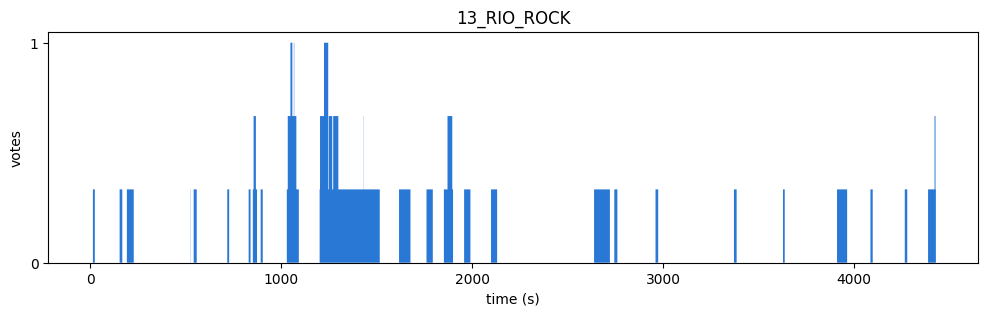

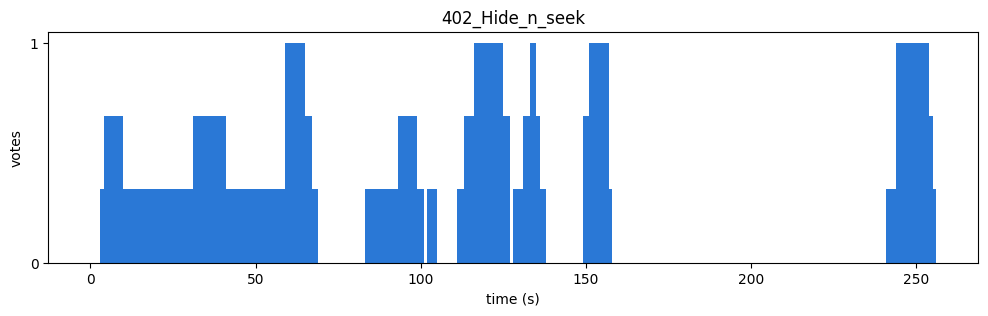

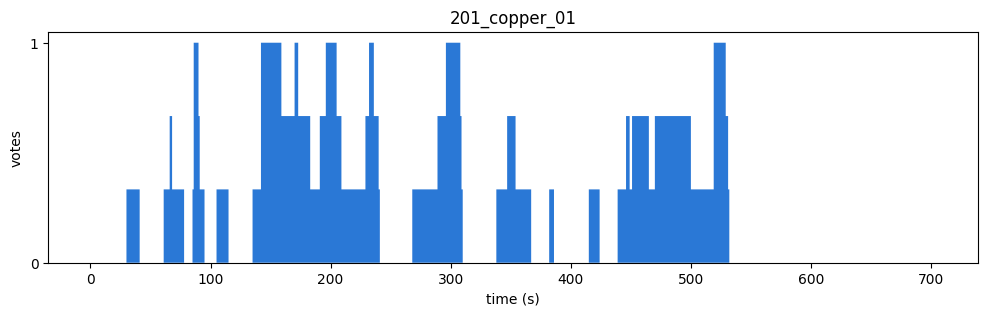

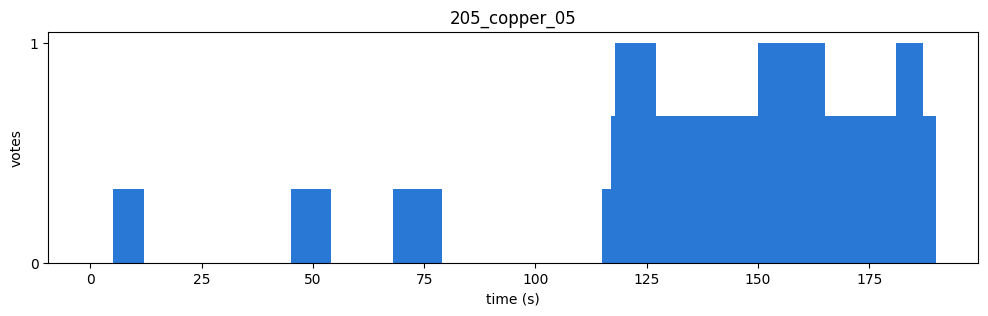

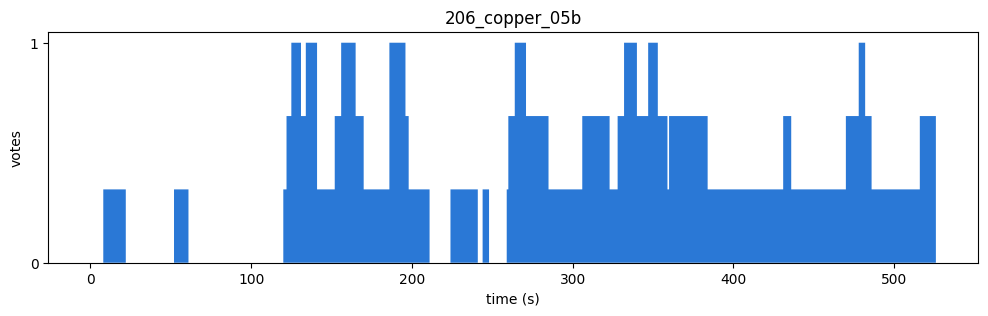

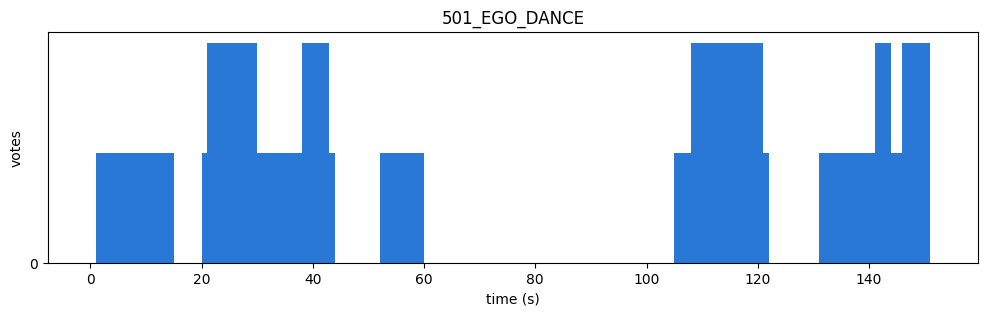

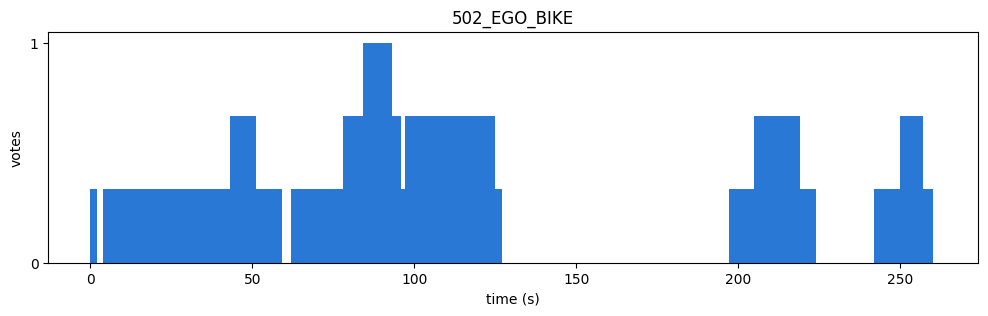

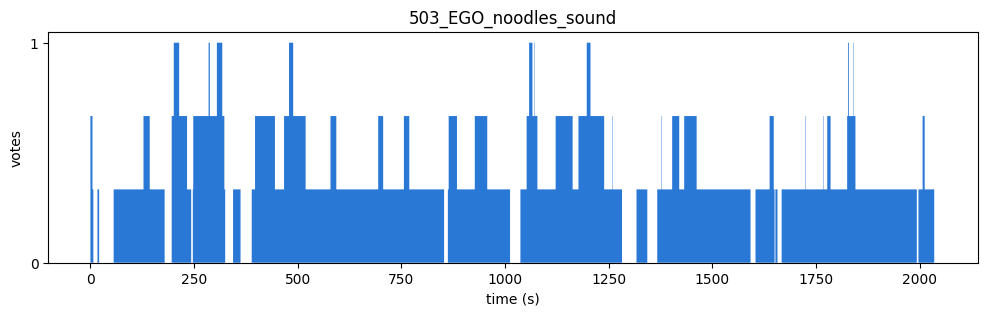

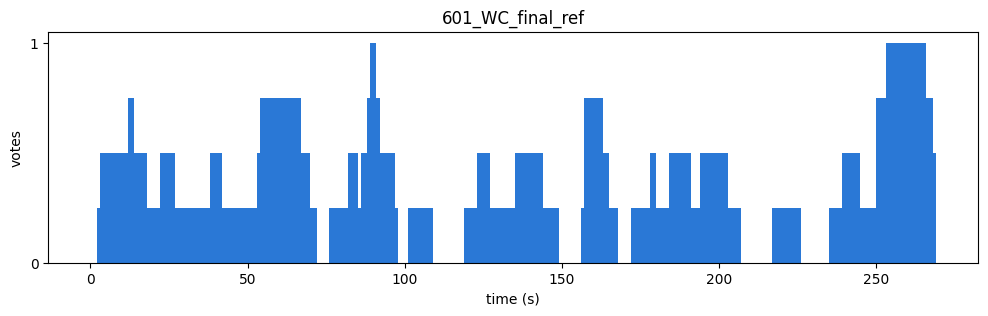

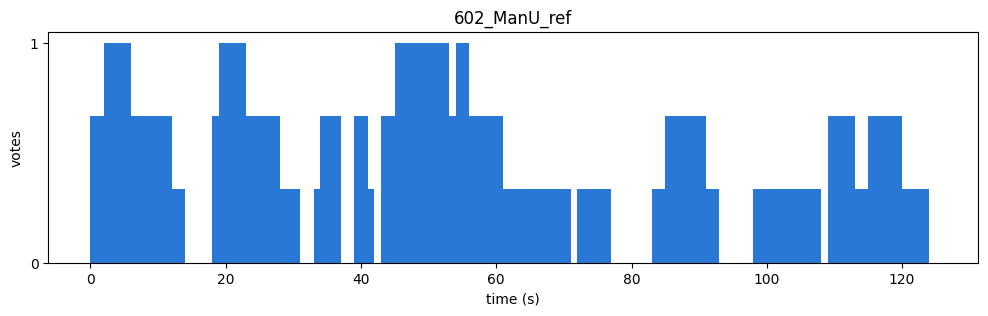

In [7]:
import matplotlib.pyplot as plt
for case in cases:
    
    edges, votes = vote_curves[case]

    fig, ax = plt.subplots(figsize=(12, 3))
    ax.stairs(votes, edges, fill=True, color="#2a78d6")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("votes")
    ax.set_yticks(range(int(votes.max()) + 1))
    ax.set_title(case)
    plt.show()


In [8]:
# proposed summary duration: case × annotator
import pandas as pd

def union_sec(beats):
    """Total seconds an annotator proposed, overlapping beats merged not double-counted."""
    tot, cs, ce = 0.0, None, None
    for s, e in sorted((b["start_sec"], b["end_sec"]) for b in beats):
        if cs is None:
            cs, ce = s, e
        elif s <= ce:
            ce = max(ce, e)
        else:
            tot += ce - cs
            cs, ce = s, e
    return tot + (ce - cs if cs is not None else 0.0)


runtimes, cells = {}, {}
for case in cases:
    for l in load_labels(case):                      # load_labels already set_case()s
        runtimes[case] = l["video_duration_sec"]
        cells[(case, l["annotator"])] = union_sec(l["beats"])

annotators = sorted({a for _, a in cells})
proposed = pd.DataFrame(index=cases, columns=annotators, dtype=float)  # NaN where not annotated
for (c, a), v in cells.items():
    proposed.loc[c, a] = v
proposed.insert(0, "runtime_s", [runtimes[c] for c in cases])

proposed_pct = proposed[annotators].div(proposed["runtime_s"], axis=0) * 100

display(proposed.round(1))
display(proposed_pct.round(1))


,runtime_s,George,Tamara,Vuk,stefanos
13_RIO_ROCK,4429.7,482.9,NaN,272.3,392.7
402_Hide_n_seek,255.5,59.9,123.8,NaN,35.9
201_copper_01,703.2,156.1,NaN,140.6,232.2
205_copper_05,189.2,NaN,71.2,55.3,70.9
206_copper_05b,525.3,175.1,341.4,94.9,NaN
501_EGO_DANCE,151.0,49.4,21.6,38.9,NaN
502_EGO_BIKE,260.5,88.9,53.3,NaN,99.6
503_EGO_noodles_sound,2038.7,404.2,NaN,338.1,1616.6
601_WC_final_ref,269.0,95.9,142.7,61.7,70.3
602_ManU_ref,124.7,37.4,61.8,65.4,NaN


,George,Tamara,Vuk,stefanos
13_RIO_ROCK,10.9,NaN,6.1,8.9
402_Hide_n_seek,23.4,48.4,NaN,14.0
201_copper_01,22.2,NaN,20.0,33.0
205_copper_05,NaN,37.6,29.2,37.5
206_copper_05b,33.3,65.0,18.1,NaN
501_EGO_DANCE,32.7,14.3,25.8,NaN
502_EGO_BIKE,34.1,20.5,NaN,38.2
503_EGO_noodles_sound,19.8,NaN,16.6,79.3
601_WC_final_ref,35.7,53.1,22.9,26.1
602_ManU_ref,30.0,49.6,52.4,NaN


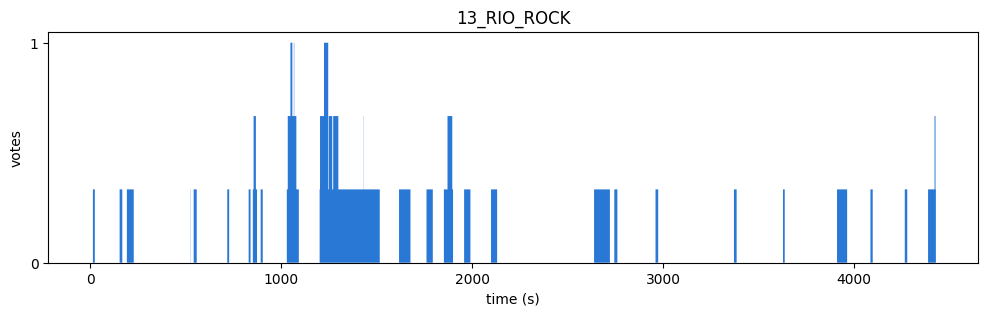

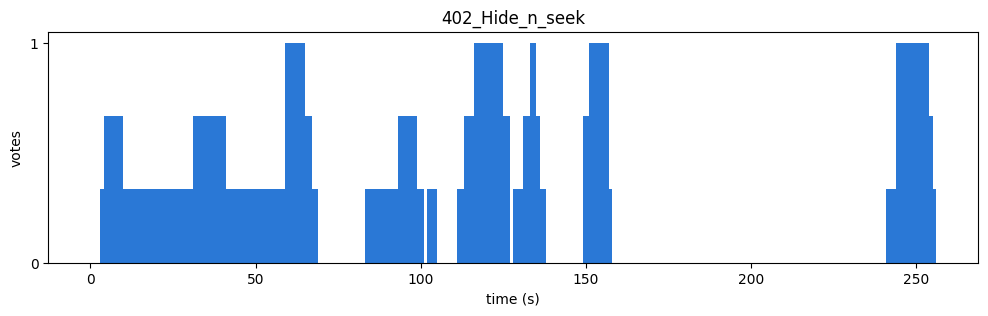

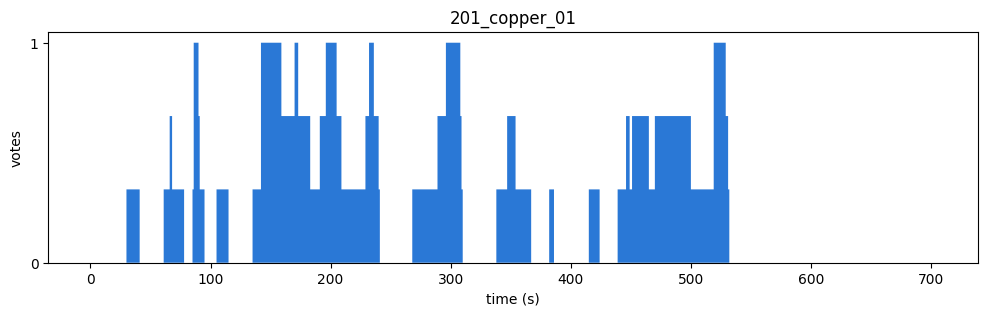

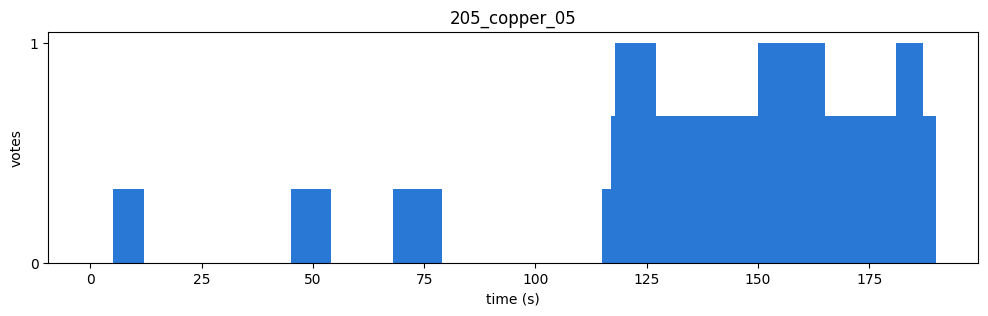

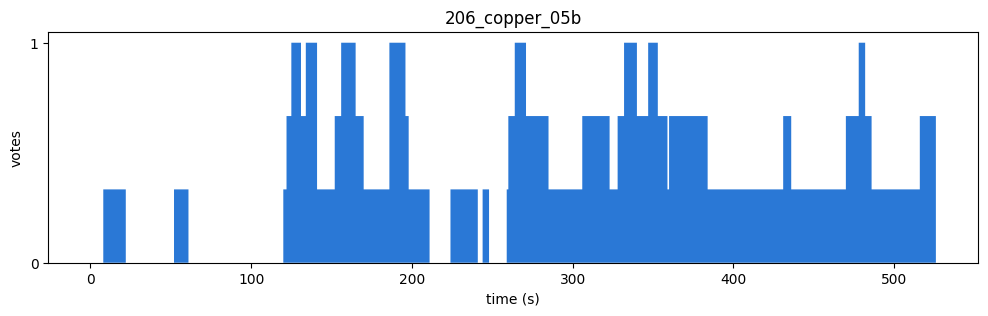

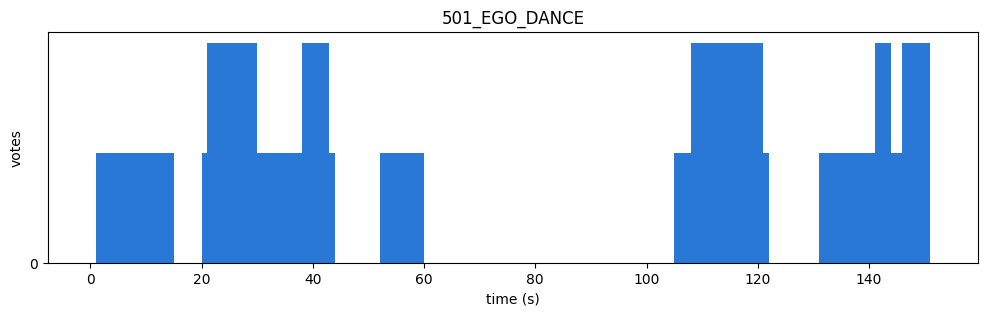

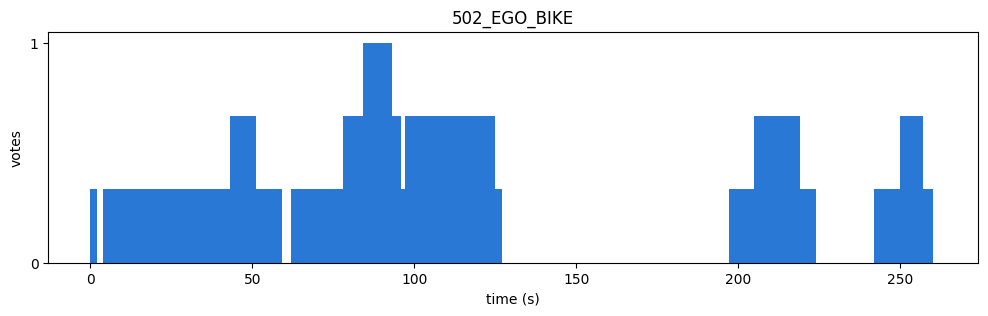

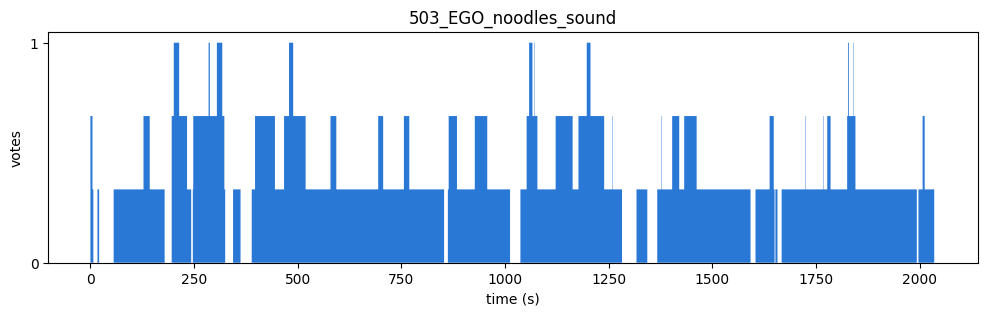

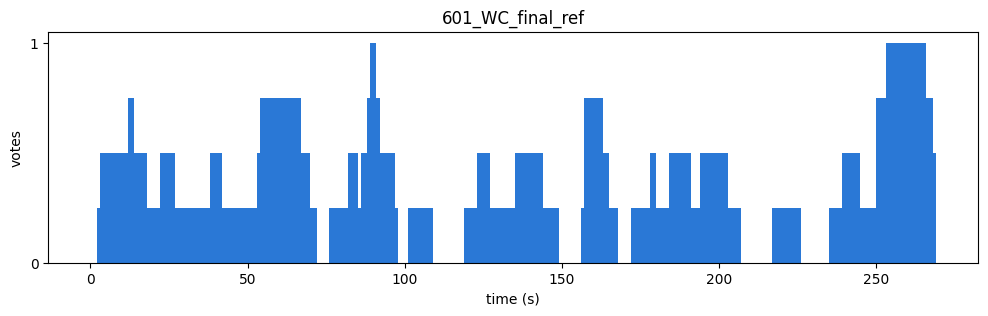

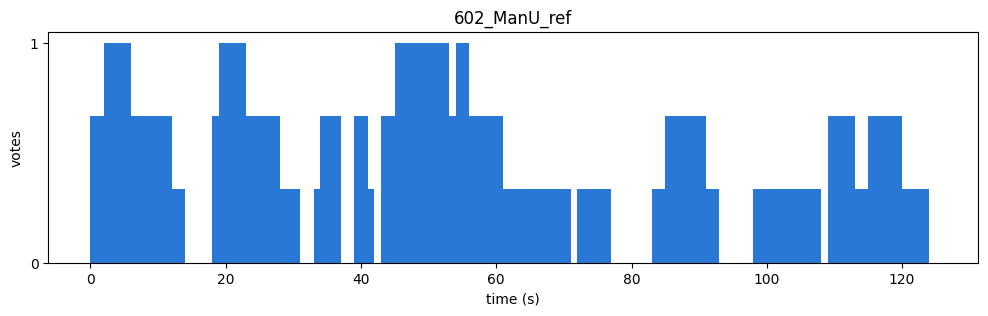

In [9]:
import matplotlib.pyplot as plt
for case in cases:
    
    edges, votes = vote_curves[case]

    fig, ax = plt.subplots(figsize=(12, 3))
    ax.stairs(votes, edges, fill=True, color="#2a78d6")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("votes")
    ax.set_yticks(range(int(votes.max()) + 1))
    ax.set_title(case)
    plt.show()


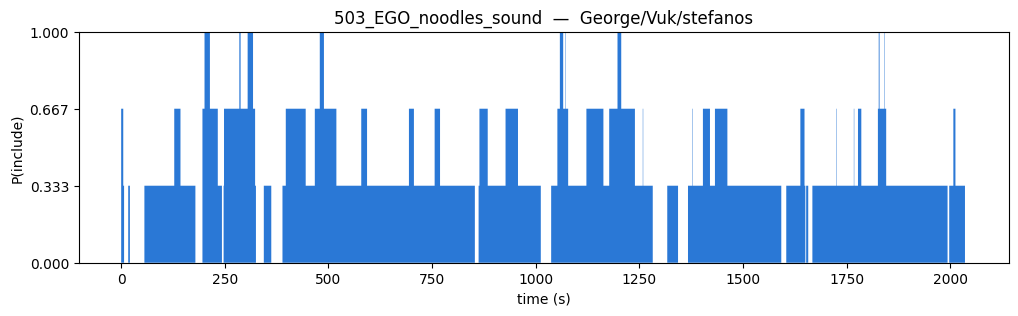

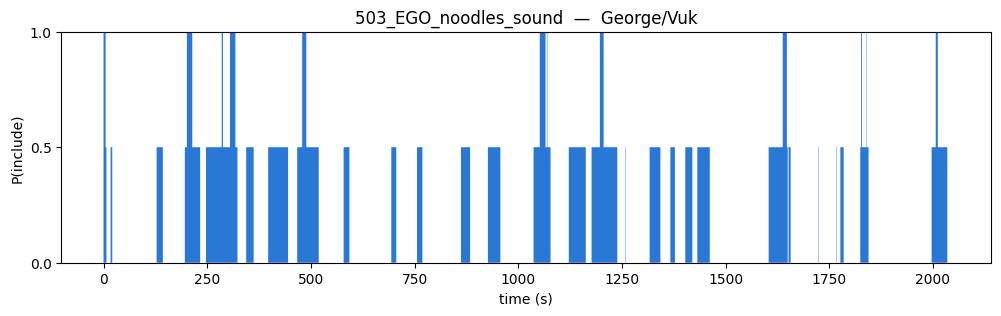

In [10]:
def vote_curve(case, exclude=()):
  
    """exclude: annotator names to drop, e.g. exclude=["stefanos"]"""
    labels = [l for l in load_labels(case) if l["annotator"] not in exclude]
    assert labels, f"{case}: excluded everyone"
    n_ann = len(labels)
    edges, votes = importance_votes(labels)
    return edges, votes,  n_ann, [l["annotator"] for l in labels]



def plot_votes(case, exclude=()):
    edges, votes, n_ann, names = vote_curve(case, exclude)
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.stairs(votes, edges, fill=True, color="#2a78d6")
    ax.set_yticks(np.arange(n_ann + 1) / n_ann)
    ax.set_ylim(0, 1)
    ax.set_xlabel("time (s)")
    ax.set_ylabel("P(include)")
    ax.set_title(f"{case}  —  {'/'.join(sorted(names))}")
    plt.show()
    return edges, votes


plot_votes("503_EGO_noodles_sound")                          # all three
no_stef_edges, no_stef = plot_votes("503_EGO_noodles_sound", exclude=["stefanos"])    # George + Vuk


In [11]:
from B_video_processing import frame_times_at_indices
from A_Config import set_case, source_video_path


def paper_edit_to_timegrid(paper_edit_json_path, case_name, edges):
    """Paper edit -> per-second kept/not, on the same grid as the vote curve.
    Beat bounds are frame indices, converted via each frame's own decoded
    timestamp (no fps assumption). Unresolved beats are skipped and reported."""
    n = len(edges) - 1
    bin_s = edges[1] - edges[0]

    beats = json.loads(Path(paper_edit_json_path).read_text())["beats"]
    pairs = [(b["start_frame"], b["end_frame"]) for b in beats
             if b.get("start_frame") is not None and b.get("end_frame") is not None]
    skipped = len(beats) - len(pairs)
    if skipped:
        print(f"{case_name}: {skipped}/{len(beats)} beats have no resolved frames — skipped")

    set_case(case_name)
    times = frame_times_at_indices(source_video_path(),
                                   {f for pair in pairs for f in pair})  # ONE pass

    included = np.zeros(n, dtype=bool)
    for f0, f1 in pairs:
        if f0 not in times or f1 not in times:      # frame past end of video
            print(f"{case_name}: frames {f0}-{f1} outside video — skipped")
            continue
        start_s, end_s = times[f0], times[f1]
        i0 = max(0, int(np.floor(start_s / bin_s)))
        # ceil so a partly-covered bin still counts; max(i0+1,…) so a beat
        # shorter than one bin still claims one
        i1 = min(n, max(i0 + 1, int(np.ceil(end_s / bin_s))))
        included[i0:i1] = True
    duration = included.sum() *bin_s
    return included , duration
    
def score_paper_edit(votes, in_edit, n_ann, tau=None):
    """Grade one paper edit against the human importance curve.
    using w^2 to really emphasise it when the majority think something is important
    ."""
    w = votes
    #multiplier
    g = w**2
    if tau is None:
        tau = (1.0 / n_ann)**2
    bin_s = 1.0 if not hasattr(g, "bin_s") else g.bin_s
    bin_s = BIN_S

    score = float((g[in_edit] - tau).sum())
    best = float(np.maximum(g - tau, 0).sum())
    consensus = w > 0.5                       # strictly more than half, any n_ann
    kept_s = float(in_edit.sum() * bin_s)
    duration = in_edit.sum() * bin_s
    return dict(
        raw_score      = score,
        score_per_s    = score/duration,
        vs_votes       = score / best if best else np.nan,
        recall_w_sq    = float(g[in_edit].sum() / g.sum()) if g.sum() else np.nan,
        junk_frac      = float((g[in_edit] == 0).mean()) if in_edit.any() else np.nan,
        missed_cons_s  = float((consensus & ~in_edit).sum() * bin_s),
        kept_s         = kept_s,
        compression    = kept_s / (len(g) * bin_s),
        tau            = tau,
        n_ann          = n_ann,
    )
def _dilate1(m):
    out = m.copy()
    out[1:] |= m[:-1]
    out[:-1] |= m[1:]
    return out


def proximity_credit(mask, decay_s=4.0):
    """1.0 inside the mask, falling linearly to 0 at decay_s seconds away."""
    steps = max(1, int(round(decay_s / BIN_S)))
    credit = mask.astype(float)
    cur = mask.copy()
    for d in range(1, steps):
        cur = _dilate1(cur)
        credit = np.maximum(credit, (1 - d / steps) * cur)
    return credit


def score_paper_vs_GT_edits(GT_edit, paper_edit, beta=1.0, decay_s=4.0):
    """Grade one paper edit against my reference cut.

    Both args are boolean masks on the same grid. TN is deliberately not scored —
    correct exclusions outnumber everything else and would swamp the result.

    Hard metrics treat a second as in or out. Soft metrics give partial credit by
    proximity: a kept second 1s outside my cut scores 0.75, 2s 0.5, 3s 0.25, and
    4s+ nothing — so sloppy boundaries barely register but isolated junk is fully
    punished. Symmetric: a GT second just outside their cut counts as nearly
    covered rather than a full miss."""
    assert GT_edit.shape == paper_edit.shape, "masks on different grids"

    tp = float((paper_edit & GT_edit).sum())
    fp = float((paper_edit & ~GT_edit).sum())
    fn = float((~paper_edit & GT_edit).sum())
    tn = float((~paper_edit & ~GT_edit).sum())

    # correct vs total in the paper edit
    precision = tp / (tp + fp) if (tp + fp) else np.nan     # did it trim like me
    # correct vs total in the GT
    recall    = tp / (tp + fn) if (tp + fn) else np.nan     # did it find my material
    #correct omissions (paper) vs all my omissions
    specificity = tn /(tn + fp) if (tn + fp)else np.nan

    # correct vs all seconds in ANY cut
    iou       = tp / (tp + fp + fn) if (tp + fp + fn) else np.nan
    f_beta    = ((1 + beta**2) * precision * recall / (beta**2 * precision + recall)
                 if precision and recall else 0.0)

    # boundary-tolerant versions
    soft_gt = proximity_credit(GT_edit, decay_s)
    soft_paper_edit = proximity_credit(paper_edit, decay_s)
    soft_precision = float(soft_gt[paper_edit].mean()) if paper_edit.any() else np.nan
    soft_recall    = float(soft_paper_edit[GT_edit].mean())  if GT_edit.any() else np.nan
    #is it in the paper edit, if yes, get the GT value (0 is neg, frac if near + 1 if +), 
    # if no get 1 (Tn). Then restrict to just the bits NOT in the GT (which is TN and FP)
    soft_specificity =float(np.where(paper_edit, soft_gt,1.0)[~GT_edit].mean())
    soft_f1 = (2 * soft_precision * soft_recall / (soft_precision + soft_recall)
               if soft_precision and soft_recall else 0.0)

    # fragmentation — reported, not scored; use it as a gate
    d = np.diff(np.concatenate(([0], paper_edit.view(np.int8), [0])))
    starts, ends = np.flatnonzero(d == 1), np.flatnonzero(d == -1)
    seg_lens = (ends - starts) * BIN_S

    return dict(
        soft_f1        = soft_f1,
        soft_precision = soft_precision,
        soft_recall    = soft_recall,
        soft_specificity =soft_specificity,
        specificity = specificity,
        iou            = iou,
        precision      = precision,
        recall         = recall,
        f_beta         = f_beta,
        beta           = beta,
        decay_s        = decay_s,
        tp_s           = tp * BIN_S,
        fp_s           = fp * BIN_S,
        fn_s           = fn * BIN_S,
        tn_s           = tn *BIN_S,
        edit_s         = float(paper_edit.sum() * BIN_S),
        gt_s           = float(GT_edit.sum() * BIN_S),
        len_ratio      = float(paper_edit.sum() / GT_edit.sum()) if GT_edit.any() else np.nan,
        n_segments     = len(seg_lens),
        shortest_seg_s = float(seg_lens.min()) if len(seg_lens) else np.nan,
        median_seg_s   = float(np.median(seg_lens)) if len(seg_lens) else np.nan,
    )


In [12]:
from A_Config import case_name, assets_dir, set_case, agent_p_output_dir
case  = "503_EGO_noodles_sound"
set_case(case)
paper_edit_path = agent_p_output_dir()/"Pipe_eval_01" /"503_EGO_noodles_sound_Pipe_eval_01_1_revision.json" 
#edges, w, n_ann, names = vote_curve(case, exclude=["stefanos"])
edges, w, n_ann, names = vote_curve(case)
print("time grid conversion")
machine_paper_edit , duration= paper_edit_to_timegrid(paper_edit_path, case, edges)
print("scoring")
#tau is break even cost
score_paper_edit(w, machine_cut, n_ann)


time grid conversion
503_EGO_noodles_sound: 2/14 beats have no resolved frames — skipped
scoring


NameError: name 'machine_cut' is not defined

In [ ]:
def beats_to_grid(label, edges):
    """One annotator's own selection, as a kept/not mask."""
    n = len(edges) - 1
    bin_s = edges[1] - edges[0]
    m = np.zeros(n, dtype=bool)
    for b in label["beats"]:
        i0 = max(0, int(np.floor(b["start_sec"] / bin_s)))
        i1 = min(n, max(i0 + 1, int(np.ceil(b["end_sec"] / bin_s))))
        m[i0:i1] = True
    return m


def leave_one_out(case):
    """Each annotator scored against the curve built from the others —
    the empirical human ceiling for this metric on this case."""
    labels = load_labels(case)
    rows = []
    for person in labels:
        other_people = [l for l in labels if l is not person]
        if not other_people:
            continue
        edges, _ = importance_votes(labels)          # grid from everyone
        _, v_others = importance_votes(other_people)
        r = score_paper_edit(v_others, beats_to_grid(person, edges), len(other_people))
        rows.append(dict(case=case, grader=person["annotator"], vs=len(other_people), **r))
    return rows


ceiling = pd.DataFrame([r for c in cases for r in leave_one_out(c)])
ceiling.groupby("case").vs_votes.agg(["mean", "min", "max"]).round(3)


,mean,min,max
case,,,
13_RIO_ROCK,-1.064,-2.147,-0.274
201_copper_01,0.431,0.386,0.479
205_copper_05,0.720,0.304,0.968
206_copper_05b,0.293,0.023,0.516
402_Hide_n_seek,0.576,0.363,0.856
501_EGO_DANCE,-0.766,-1.600,-0.143
502_EGO_BIKE,-0.042,-0.211,0.044
503_EGO_noodles_sound,-1.098,-3.589,0.243
601_WC_final_ref,0.452,0.376,0.546


In [ ]:
#system in leave one out
case = "503_EGO_noodles_sound"

# machine's cut, scored against each held-out pair
labels = load_labels(case)

machine = []
for held in labels:
    others = [l for l in labels if l is not held]
    _, w_o = importance_votes(others)
    machine.append(score_paper_edit(w_o, kept, len(others))["vs_votes"])

print("machine mean and 3 scores:", np.mean(machine), machine)
print("human mean, from cell above :", ceiling[ceiling.case == case].vs_votes.mean())




NameError: name 'kept' is not defined

# MY CUT
## VS machine

In [ ]:
def cut_csv_to_timegrid(csv_path, edges):
    """My reference cut -> per-second kept/not, on the vote grid."""
    n = len(edges) - 1
    bin_s = edges[1] - edges[0]
    df = pd.read_csv(csv_path)
    kept = np.zeros(n, dtype=bool)
    for s, e in zip(df.src_in_sec, df.src_out_sec):
        i0 = max(0, int(np.floor(s / bin_s)))
        i1 = min(n, max(i0 + 1, int(np.ceil(e / bin_s))))
        kept[i0:i1] = True
    return kept

my_cut_csv = labels_dir() / "503_cuts.csv"
GT_edit = cut_csv_to_timegrid(my_cut_csv, edges)   # w, 0 or 1
score_paper_vs_GT_edits(GT_edit, machine_paper_edit)


{'iou': 0.215,
 'precision': 0.35833333333333334,
 'recall': 0.34959349593495936,
 'f_beta': 0.35390946502057613,
 'beta': 1.0,
 'tp_s': 129.0,
 'fp_s': 231.0,
 'fn_s': 240.0,
 'edit_s': 360.0,
 'gt_s': 369.0,
 'len_ratio': 0.975609756097561,
 'n_segments': 12,
 'shortest_seg_s': 26.0,
 'median_seg_s': 29.0}

# VS humans

In [ ]:
rows = [dict(editor="ME (GT)", time_min=70.0,
             **score_paper_vs_GT_edits(GT_edit, GT_edit))]

rows.append(dict(editor="machine", time_min=np.nan,
                 **score_paper_vs_GT_edits(GT_edit, machine_paper_edit)))

for l in load_labels(case):
    rows.append(dict(editor=l["annotator"],
                     time_min=round(l["time_spent_sec"] / 60, 1),
                     **score_paper_vs_GT_edits(GT_edit, beats_to_grid(l, edges))))


comp = pd.DataFrame(rows)
comp[["editor", "time_min", "soft_f1",
      "soft_specificity", "specificity",
      "soft_precision", "precision",
      "soft_recall", "recall",
      "iou", "len_ratio", "n_segments", "median_seg_s"]].round(3)



NameError: name 'GT_edit' is not defined